# *Chapter 19*<br> PDE Review & Electrostatics via Finite Differences 

| | | |
|:---:|:---:|:---:|
| ![image](Figs/Cover.png)|[From **COMPUTATIONAL PHYSICS**, 3rd Ed, 2015](http://physics.oregonstate.edu/~rubin/Books/CPbook/index.html) <br>RH Landau, MJ Paez, and CC Bordeianu (deceased) <br>Copyrights: <br> [Wiley-VCH, Berlin;](http://www.wiley-vch.de/publish/en/books/ISBN3-527-41315-4/) and [Wiley & Sons, New York](http://www.wiley.com/WileyCDA/WileyTitle/productCd-3527413154.html)<br>  R Landau, Oregon State Unv, <br>MJ Paez, Univ Antioquia,<br> C Bordeianu, Univ Bucharest, 2015.<br> Support by National Science Foundation.|![image](Figs/BackCover.png)|

**19 PDE Review & Electrostatics via Finite Differences**<br>
[19.1 PDE Generalities](#19.1)<br>
[19.2 Electrostatic Potentials](#19.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[19.2.1 Laplace’s Elliptic PDE (Theory)](#19.2.1)<br>
[19.3 Fourier Series Solution of a PDE](#19.31)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[19.3.1 Polynomial Expansion As an Algorithm](#19.3.1)<br>
[19.4 Finite-Difference Algorithm](#19.4)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[19.4.1 Relaxation and Overrelaxation](#19.4.1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[19.4.2 Lattice PDE Implementation](#19.4.2)<br>
[19.5 Assessment via Surface Plot](#19.5)<br>
[19.6 Alternate Capacitor Problems](#19.6)<br>
[19.7 Implementation and Assessment](#19.7)<br>
[19.8 Electric Field Visualization (Exploration)](#19.8)<br>
[19.9 Review Exercise](#19.9)<br>

*This chapter is the first of several dealing with partial differential
equations (PDE’s); several because PDE’s are more complex than ODE’s,
and because each type of PDE requires its own algorithm. We start the
chapter with a discussion of PDE’s in general, and the requirements for
a unique solution of each type to exist. Then we get down to business
and examine the simple, but powerful, *finite-differences* method with
relaxation for solving Poisson’s and Laplace’s equations on a lattice in
space. [Chapter 3](CP23.ipynb) covers the more complicated, but
ultimately more efficient, *finite elements* method for solving the same
equations.*

** This Chapter’s Lecture, Slide Web Links, Applets & Animations**

|  | |
|---|---|
|[All Lectures](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/index.html)|[![anything](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/index.html)|

| *Lecture (Flash)*| *Slides* | *Sections*|*Lecture (Flash)*| *Slides* | *Sections*|  
|- - -|:- - -:|:- - -:|- - -|:- - -:|:- - -:|
|[Intro to PDE’s](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/VideoLecs/PDE_Intro/PDE_Intro.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/PDE's_08Mar.pdf)| 17.1 | [PDE Electrostatics I](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/VideoLecs/Elec1/Elec1.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/ElectricField_10Mar.pdf)| 17.2 |
|[Electrostatics II](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/VideoLecs/Elec2/Elec2.html)|[pdf](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook//Slides/Slides_NoAnimate_pdf/ElectricField_10Mar.pdf)| 17.4|[Finite Elements Electrostatics](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/VideoLecs/FEM/FEM.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pd/FiniteElements_26May.pdf)| 17.10 |
|[PDE Heat](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/VideoLecs/Heat/Heat.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/Heat_06Ap10.pdf)| 17.16| [Heat Crank-N](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/VideoLecs/Heat_CN/Heat_CN.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/HeatCrank_96Ap10.pdf)| 17.19 |
| [Heat Equation Applet](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/Applets/index.html)}| | | | | |

## 19.1  PDE Generalities <a id="19.1"></a>

Physical quantities such as temperature and pressure vary continuously
in both space and time. Such being our world, the function or *field*
$U(x, y, z, t)$ used to describe these quantities must contain
independent space and time variations. As time evolves, the changes in
$U(x,y,z,t)$ at any one position affect the field at neighboring points.
This means that the dynamic equations describing the dependence of $U$
on four independent space-time variables must be written in terms of
partial derivatives, and therefore the equations must be [*partial
differential
equations*](http://www.science.oregonstate.edu/~rubin/Books/CPbook/eBook/GlossarySound/pde.wav)
(PDE’s), in contrast to ordinary differential equations (ODE’s).

The most general form for a two-independent variable PDE is

$$\tag*{19.1} A \frac{\partial^2 U}{\partial x^2}+ 2B \frac{\partial^2 U}{\partial
x \partial y}+C \frac{\partial^2 U}{\partial y^2} + D \frac{\partial U}{\partial x}+E
\frac{\partial U}{\partial y} =F,$$

where $A$, $B$, $C$, and $F$ are arbitrary functions of the variables
$x$ and $y$. In the table below we define the classes of PDE’s by the
value of the discriminant $d=AC-B^2$ \[[Arfken & Weber(01)](BiblioLinked.html#arfkenweber)\], with the
rows below being examples:

**Table 19.1** Three categories of PDEs based on the value of their
determinant $D$.

|<span>*Elliptic* </span>| <span>*Parabolic*</span> | <span>*Hyperbolic*</span>| 
|-------------------------------|-------------------------------|-------------------------------| 
|$d=AC-B^2>0$                  |$d=AC-B^2=0$               |$d=AC-B^2<0$              |
|$\nabla^2 U(x) = -4\pi\rho(x)$          |$\nabla^2 U(\mathbf{x},t) =a \partial U/\partial t$        | $\nabla^2 U(\mathbf{x},t)=c^{-2}\partial^2 U/\partial t^2\mbox{}$  |


We usually think of an elliptic equation as containing second-order
derivatives of all the variables, with all having the same sign when
placed on the same side of the equal sign; a parabolic equation as
containing a first-order derivative in one variable and a second-order
derivative in the other; and a hyperbolic equation as containing
second-order derivatives of all the variables, with opposite signs when
placed on the same side of the equal sign.

After solving enough problems, one often develops some physical
intuition as to whether one has sufficient *boundary conditions* for
there to exist a unique solution for a given physical situation (this,
of course, is in addition to requisite *initial conditions*). Table 19.2
gives the requisite boundary conditions for a unique solution to exist
for each type of PDE. For instance, a string tied at both ends and a
heated bar placed in an infinite heat bath are physical situations for
which the boundary conditions are adequate. If the boundary condition is
the value of the solution on a surrounding closed surface, we have a
*Dirichlet boundary condition*. If the boundary condition is the value
of the normal derivative on the surrounding surface, we have a *Neumann
boundary condition*. If the value of both the solution and its
derivative are specified on a closed boundary, we have a *Cauchy
boundary condition.* Although having an adequate boundary condition is
necessary for a unique solution, having too many boundary conditions,
for instance, both Neumann and Dirichlet, may be an overspecification
for which no solution exists.\[*Note:* Although conclusions drawn for
exact PDE’s may differ from those drawn for the finite-difference
equations we use for our algorithms, they are usually the same. In fact,
\[[Morse & Feshbach(53)](BiblioLinked.html#morse)\] use the finite-difference
form to derive the relations between boundary conditions and uniqueness
for each type of equation shown in Table 19.2 \[[Jackson(88)](BiblioLinked.html#jackson)\].\]

**Table 19.2** Relation Between Boundary Conditions and Uniqueness for
PDE’s.

|Boundary Conditon|Elliptic |Hyperbolic|Parabolic|
|---|---|---|---|
|Dirichlet open surface|Underspecified |Underspecified |*Unique + stable (1-D)*|
|Dirichlet closed surface |*Unique & stable* |Overspecified |Overspecified|
|Neumann open surface |Underspecified |Underspecified |*Unique & Stable(1-D)*|
|Neumann closed surface |*Unique & stable* |Overspecified |Overspecified|
|Cauchy open surface |Nonphysical |*Unique & stable* |Overspecified|
|Cauchy closed surface |Overspecified |Overspecified| Overspecified|

Solving PDE’s numerically differs from solving ODE’s in a number of
ways. First, because we are able to write all ODE’s in a standard form,

$$\tag*{19.2}
\frac{d\mathbf{y}(t)} {dt} =  \mathbf{f}(\mathbf{y}, t),$$

with $t$ the single independent variable, we are able to use a standard
algorithm such as `rk4` to solve all such equations. Yet because PDE’s
have several independent variables, for example, $\rho(x,y,z,t)$, we
would have to apply (19.2) simultaneously and independently to each
variable, which would be very complicated. Second, because there are
more equations to solve with PDE’s than with ODE’s, we need more
information than just the two *initial conditions* $[x(0)$,
$\dot{x}(0)]$. In addition, because each PDE often has its own
particular set of boundary conditions, we have to develop a special
algorithm for each particular problem.


## 19.2  Electrostatic Potentials <a id="19.21"></a>

[![image](Figs/RHLlectureMod4.png)](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/VideoLecs/Elec1/Elec1.html)

Your **problem** is to find the electric potential for all points
*inside* the charge-free square shown in Figure 19.1. The bottom and
sides of the region are made up of wires that are “grounded” (kept at 0
V). The top wire is connected to a voltage source that keeps it at a
constant 100 V.

![image](Figs/Fig19_1.png)

**Figure 19.1** *Top:* The shaded region of space within a square in which we
determine the electric potential by solving Laplace’s equation. There is a wire at
the top kept at a constant 100 V and a grounded wire (dashed) at the sides and
bottom. *Bottom:* The computed electric potential as a function of $\textit{x}$
and $\textit{y}$. The projections onto the shaded $\textit{xy}$ plane are
equipotential (contour) lines.

### 19.2.1  Laplace’s Elliptic PDE (Theory)<a id="19.2.1"></a>

We consider the entire square in Figure 19.1 as our boundary with the
voltages prescribed upon it. If we imagine infinitesimal insulators
placed at the top corners of the box, then we will have a closed
boundary. Because the values of the potential are given on all sides, we
have Neumann conditions on the boundary and, according to Table 19.2, a
unique and stable solution.

It is known from classical electrodynamics that the electric potential
$U(\textbf{x})$ arising from static charges satisfies Poisson’s PDE
\[[Jackson(88)](BiblioLinked.html#jackson)\]:

$$\tag*{19.3}
\nabla^2 U(\textbf{x}) = - 4 \pi \rho(\textbf{x}),$$

where $\rho(\textbf{x})$ is the charge density. In charge-free regions
of space, that is, regions where $\rho(\textbf{x})=0$, the potential
satisfies *Laplace’s equation*:

$$\tag*{19.4}
\nabla^2 U(\textbf{x}) = 0.$$

Both these equations are elliptic PDE’s of a form that occurs in various
applications. We solve them in 2-D rectangular coordinates:

$$\begin{align}
\tag*{19.5}
\frac{\partial^2 U(x,y)}{\partial x^2}+ \frac{\partial^2
U(x,y)}{\partial y^2 } & = 0, &\mbox{Laplace's equation,} \\
\frac{\partial^2 U(x,y)}{\partial x^2}+ \frac{\partial^2
U(x,y)}{\partial y^2 } & = - 4 \pi \rho(\textbf{x}), & \mbox{Poisson's equation}.
\tag*{19.6}\end{align}$$

In both cases we see that the potential depends simultaneously on $x$
and $y$. For Laplace’s equation, the charges, which are the source of
the field, enter indirectly by specifying the potential values in some
region of space; for Poisson’s equation they enter directly.

## 19.3  Fourier Series Solution of a PDE <a id="19.3"></a>

For the simple geometry of Figure 19.1 an analytic solution of Laplace’s
equation (19.5) exists in the form of an infinite series. If we assume
that the solution is the product of independent functions of $x$ and $y$
and substitute the product into (19.5), we obtain

$$\tag*{19.7} U(x,y)=X(x)Y(y)\ \Rightarrow\ \frac{d^2
X(x)/dx^2}{X(x)} + \frac{d^2Y(y)/dy^2}{Y(y)}=0.$$

Because $X(x)$ is a function of only $x$, and $Y(y)$ is a function of only $y$, the
derivatives in (19.7) are *ordinary* as opposed to *partial* derivatives. Because
$X(x)$ and $Y(y)$ are assumed to be independent, the only way (19.7) can be
valid for *all* values of $x$ and $y$ is for each term in (19.7) to be equal to a
constant:

$$\begin{align}
\tag*{19.8}
\frac{d^2Y(y)/dy^2}{Y(y)} & =  - \frac{d^2X(x)/ dx^2}{X(x)} =
k^2,\\
\Rightarrow\quad \frac{d^2X(x)}{dx^2}+ k^2 X(x)  & =   0, \qquad
\frac{d^2 Y(y)}{dy^2}- k^2Y(y) = 0.\tag*{19.9}\end{align}$$

We shall
see that this choice of sign for the constant matches the boundary
conditions and gives us periodic behavior in $x$. The other choice of
sign would give periodic behavior in $y$, and that would not work with
these boundary conditions.

![image](Figs/Fig19_2.png)

**Figure 19.2** The analytic (Fourier series) solution of Laplace’s equation
summing 21 terms. Gibbs-overshoot leads to the oscillations near
$\textit{x}=\text{0}$, and persist even if a large number of terms is summed.

The solutions for $X(x)$ are periodic, and those for $Y(y)$ are
exponential:

$$\tag*{19.10} X(x) = A \sin kx + B\cos kx, \quad Y(y) = C e^{ky} + D e^{-ky}.$$

The $x=0$ boundary condition $U(x=0,y)=0$ can be met only if $B=0$. The
$x=L$ boundary condition $U(x=L,y)=0$ can be met only for

$$\tag*{19.11} kL=n\pi, \quad n=1,2, \ldots .$$

Such being the case, for each value of $n$ there is the solution

$$\tag*{19.12} X_n(x)=A_n \sin \left(\frac{n\pi}{L}x \right).$$

For each value of $k_n$, $Y(y)$ must satisfy the $y$ boundary condition
$U(x,0)=0$, which requires $D=-C$:

$$\tag*{19.13} Y_n(y) = C(e^{k_ny}-e^{-k_ny}) \equiv 2C \sinh
\left(\frac{n\pi}{L}y \right).$$

Because we are solving linear equations, the principle of linear
superposition holds, which means that the most general solution is the
sum of the products:

$$\tag*{19.14} U(x,y) =\sum_{n=1}^\infty E_n \sin \left(\frac{n\pi}{L}x\right)
  \sinh \left(\frac{n\pi}{L}y\right).$$

The $E_n$ values are arbitrary constants and are fixed by requiring the
solution to satisfy the remaining boundary condition at $y=L$,
$U(x,y=L)=$ 100 V:

$$\tag*{19.15}
\sum_{n=1}^\infty E_n   \sin  \frac{n\pi}{L}x   \sinh n\pi
=100 \mbox{V}.$$

We determine the constants $E_n$ by projection: multiply both sides of
the equation by $\sin m\pi/L x$, with $m$ an integer, and integrate from
$0$ to $L$:

$$\tag*{19.16}
\sum_n^\infty  E_n   \sinh n\pi\int_0^L \!dx \sin
\frac{n\pi}{L}x   \sin  \frac{m\pi}{L}x = \int_0^L\! dx
100 \sin  \frac{m\pi}{L}x.$$

The integral on the LHS is nonzero only for $n=m$, which yields

$$\tag*{19.17} E_n =\begin{cases}0, & \mbox{for }\ n\ \mbox{even},\\
\frac{4(100)}{n\pi   \sinh n\pi}, & \mbox{for } \ n\ \mbox{odd}.
 \end{cases}$$

Finally, we obtain an infinite series (analytic solution?) for the
potential at any point $(x,y)$:

$$\tag*{19.18} U(x,y)=\sum_{n=1,3,5,\ldots}^\infty \frac{400}{n\pi} \sin
\left(\frac{n\pi x}{L}\right)  \frac{\sinh (n\pi y/L)}{\sinh
(n\pi)}.$$

### 19.3.1  Polynomial Expansion As an Algorithm<a id="19.3.1"></a>

If we try to use (19.18) as an algorithm, we must terminate the sum at
some point. Yet in practice the convergence of the series is so
painfully slow that many terms are needed for good accuracy, and so
round-off error may become a problem. In addition, the $\sinh$ functions
in (19.18) overflow for large $n$, which can be avoided somewhat by
expressing the quotient of the two $\sinh$ functions in terms of
exponentials and then taking a large $n$ limit:

$$\tag*{19.19}
\frac{\sinh (n\pi y/L)}{\sinh(n\pi)}= \frac{e^{n\pi(y/L -1)}
-e^{-n\pi(y/L +1)}}{1-e^{-2n\pi}}   \underset{n\rightarrow \infty}{\rightarrow}
  e^{n\pi(y/L
-1)}.$$

A third problem with the “analytic” solution is that a Fourier series
converges only in the *mean square* (Figure 19.2). This means that it
converges to the *average* of the left- and right-hand limits in the
regions where the solution is discontinuous \[[Kreyszig(98)](BiblioLinked.html#kreysig)\], such as in
the corners of the box. Explicitly, what you see in Figure 19.2 is a
phenomenon known as the **Gibbs overshoot** that occurs when a Fourier
series with a finite number of terms is used to represent a
discontinuous function. Rather than fall off abruptly, the series
develops large oscillations that tend to overshoot the function at the
corner. To obtain a smooth solution, we had to sum 40,000 terms, where,
in contrast, the numerical solution required only several hundred steps.

## 19.4  Finite-Difference Algorithm  <a id="19.4"></a>

[![image](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/Elec2/Elec2.html)

To solve our 2-D PDE numerically, we divide space up into a lattice
(Figure 19.3) and solve for $U$ at each site on the lattice. Because we
will express derivatives in terms of the finite differences in the
values of $U$ at the lattice sites, this is called a *finite-difference*
method. A numerically more efficient method, but with more complicated
set up, is the *finite-element* method (FEM) that solves the PDE for
small geometric elements and then matches the solution over the
elements. We discuss FEM in [Chapter 23](CP23.ipynb).

![image](Figs/Fig19_3.png)

**Figure 19.3** The algorithm for Laplace’s equation in which the potential at
the point $(\textit{x},\textit{y}) =(\textit{i},\textit{j})\Delta$ equals the average
of the potential values at the four nearest-neighbor points. The nodes with
white centers correspond to fixed values of the potential along the boundaries.

To derive the finite-difference algorithm for the numeric solution of (19.5), we
follow the same path taken in §5.1 to derive the forward-difference algorithm
for differentiation. We start by adding the two Taylor expansions of the
potential to the right and left of $(x,y)$ and the two for above and below
$(x,y)$:

$$\begin{align}
\tag*{19.20}
U(x +\Delta x, y) & = U(x,y) + \frac{\partial U}{\partial x}\Delta x + \frac{1}{2}
\frac{\partial^2 U}{\partial x^2}(\Delta x)^2 + \cdots, \\
U(x -\Delta x, y) & = U(x,y) - \frac{\partial U}{\partial x}
\Delta x + \frac{1} {2} \frac{\partial^2 U}{\partial x^2} (\Delta
x)^2 - \cdots.\tag*{19.21}\\
U(x, y +\Delta y) & = U(x,y) + \frac{\partial
U}{\partial y}\Delta y + \frac{1}{2} \frac{\partial^2 U}{\partial y^2}(\Delta y)^2 +
\cdots, \tag*{19.22}\\
U(x, y -\Delta y) & = U(x,y) - \frac{\partial U}{\partial y}
\Delta y + \frac{1} {2} \frac{\partial^2 U}{\partial y^2} (\Delta
y)^2 - \cdots.\tag*{19.23}\end{align}$$

All odd terms cancel when we add these
equations in pairs, and we obtain a central-difference approximation for the
second partial derivative good to order $\Delta^4$:

$$\begin{align}
\tag*{19.24}
\frac{\partial^2 U(x,y)}{\partial x^2}& \simeq   \frac{U(x+\Delta
x,y)+U(x-\Delta x,y)-2 U(x,y)}{(\Delta x)^2}\\
\frac{\partial^2 U(x,y)}{\partial y^2} & \simeq   \frac{U(x,y+\Delta y) +U(x, y-\Delta y)-2 U(x,y)}{(\Delta
y)^2} \tag*{19.25}\end{align}$$

Substitution of both these approximations in
Poisson’s equation (19.6) leads us to a finite-difference form of the PDE:

$$\begin{align}
\tag*{19.26}
&\frac{U(x+\Delta x,y) + U(x-\Delta x,y)-2 U(x,y)}{(\Delta x)^2}\\
&\qquad + \frac{U(x,y+\Delta y) + U(x,y-\Delta y)-2 U(x,y)}{(\Delta y)^2} =
-4\pi\rho.\tag*{19.27}\end{align}$$ 

We take the $x$ and $y$ grids to be of
equal spacings $\Delta x=\Delta y=\Delta$, and thus obtain a simple form for
the equation:

$$\tag*{19.28}
 {U(x+\Delta ,y) + U(x-\Delta ,y)}+ {U(x,y+\Delta ) +
U(x,y-\Delta )-4 U(x,y) }
  =  -4\pi\rho.$$

The reader will notice that this equation shows a relation among the
solutions at five points in space. When $U(x,y)$ is evaluated for the
$N_x$ $x$ values on the lattice and for the $N_y$ $y$ values, we obtain
a set of $N_x\times N_y$ simultaneous linear algebraic equations for
`U[i,j]` to solve. One approach is to solve these equations explicitly
as a (big) matrix problem. This is attractive, as it is a direct
solution, but it requires a great deal of memory and accounting. The
approach we use follows from the algebraic solution of (19.28) for
$U(x,y)$:

$$\tag*{19.29} 4U(x,y) \simeq U(x+\Delta,y) +U(x-\Delta,y)+U(x,y +\Delta) + U(x,y-\Delta)
  + 4\pi\rho(x,y)\Delta^2,$$

where we would omit the $\rho(x)$ term for Laplace’s equation. In terms
of discrete locations on our lattice, the $x$ and $y$ variables are

$$\tag*{19.30} x = x_0 + i \Delta, \quad y = y_0 + j \Delta, \quad i,j=0,\ldots,
N_{\textrm max-1},$$

where we have placed our lattice in a square of side $L$. The
finite-difference algorithm (19.29) becomes

$$\tag*{19.31}
  \boxed{U_{i,j} =\frac{1}{4} \left[U_{i+1,j}+U_{i-1,j}
 + U_{i,j+1} + U_{i,j-1} \right]+ \pi\rho(i\Delta, j\Delta)\Delta^2.}$$

This equation says that when we have a proper solution, it will be the
average of the potential at the four nearest neighbors (Figure 19.3)
plus a contribution from the local charge density. As an algorithm,
(19.31) does not provide a direct solution to Poisson’s equation, but
rather must be repeated many times to converge upon the solution. We
start with an initial guess for the potential, improve it by sweeping
through all space taking the average over nearest neighbors at each
node, and keep repeating the process until the solution no longer
changes to some level of precision or until failure is evident. When
converged, the initial guess is said to have *relaxed* into the
solution.

A reasonable question with this simple an approach is, “Does it always
converge, and if so, does it converge fast enough to be useful?” In some
sense the answer to the first question is not an issue; if the method
does not converge, then we will know it; otherwise we have ended up with
a solution and the path we followed to get there is no body’s business!
The answer to the question of speed is that relaxation methods may
converge slowly (although still faster than a Fourier series), yet we
will show you two clever tricks to accelerate the convergence.

At this point it is important to remember that our algorithm arose from
expressing the Laplacian $\nabla^2$ in rectangular coordinates. While
this does not restrict us from solving problems with circular symmetry,
there may be geometries where it is better to develop an algorithm based
on expressing the Laplacian in cylindrical or spherical coordinates in
order to have grids that fit the geometry better.

### 19.4.1  Relaxation and Overrelaxation<a id="19.4.1"></a>

Therea are a number of ways in which the algorithm (19.31) can be
iterated so as to convert the boundary conditions to a solution. Its
most basic form is the <span>*Jacobi method*</span> and is one in which
the potential values are not changed until an entire sweep of applying
(19.31) at each point is completed. This maintains the symmetry of the
initial guess and boundary conditions. A rather obvious improvement on
the Jacobi method utilizes the updated guesses for the potential in
(19.31) as soon as they are available. As a case in point, if the sweep
starts in the upper-left-hand corner of Figure 19.3, then the leftmost
`U([ -1, j]` and topmost `U[i,j - 1]` values of the potential used will
be from the present generation of guesses, while the other two values of
the potential will be from the previous generation: (Gauss-Seidel
method)

$$\tag*{19.32} U^{\rm(new)}_{i,j} = \frac{1}{4}\left[U^{\rm (old)}_{i+1,j} +
U^{\rm (new)}_{i-1,j} + U^{\rm (old)}_{i,j+1} + U^{\rm (new)}_{i,j-1} \right]$$

This technique, known as the *Gauss-Seidel method*, usually leads to
accelerated convergence, which in turn leads to less round-off error. It
also uses less memory as there is no need to store two generations of
guesses. However, it does distort the symmetry of the boundary
conditions, which one hopes is insignificant when convergence is
reached.

A less obvious improvement in the relaxation technique, known as *successive
overrelaxation* (SOR), starts by writing the algorithm (19.29) in a form that
determines the new values of the potential $U^{\rm (new)}$ as the old values
$U^{\rm (old)}$ plus a correction or residual $r$:

$$\begin{align}
\tag*{19.33}
U^{\rm (new)}_{i,j} = U^{\rm (old)}_{i,j} + r_{i,j}.\end{align}$$ 

While the
Gauss-Seidel technique may still be used to incorporate the updated values in
$U^{\rm (old)}$ to determine $r$, we rewrite the algorithm here in the general
form: 

$$\begin{align}
\tag*{19.34}
r_{i,j}  &\equiv  U^{\rm (new)}_{i,j} - U^{\rm (old)}_{i,j}
\\
& = \frac{1}{4}\left[U^{\rm (old)}_{i+1,j} + U^{\rm (new)}_{i -1,j} + U^{\rm
(old)}_{i,j+1} + U^{\rm (new)}_{i,j-1} \right] -U^{\rm (old)}_{i,j}.\end{align}$$

The
successive overrelaxation technique \[Press et al.(94), Garcia(00)\] proposes
that if convergence is obtained by adding $r$ to $U$, then more rapid
convergence might be obtained by adding more or less of $r$:

$$\tag*{19.35} U^{\rm (new)}_{i,j} = U^{\rm (old)}_{i,j} +
\omega r_{i,j},  \quad \mbox{(SOR), }$$

where $\omega$ is a parameter that amplifies or reduces the residual.
The nonaccelerated relaxation algorithm (19.32) is obtained with
$\omega=1$, accelerated convergence (overrelaxation) is obtained with
$\omega\ge 1$, and underrelaxation is obtained with $\omega <1$. Values
of $1\leq
\omega \leq 2$ often work well, yet $\omega > 2$ may lead to numerical
instabilities. Although a detailed analysis of the algorithm is needed
to predict the optimal value for $\omega$, we suggest that you explore
different values for $\omega$ to see which one works best for your
particular problem.

### 19.4.2  Lattice PDE Implementation<a id="19.4.2"></a>

In Listing 19.1 we present the code `LaplaceLine.py` that solves the
square-wire problem (Figure 19.1). Here we have kept the code simple by
setting the length of the box $L = N_{\text{max}}\Delta = 100$ and by taking
$\Delta=1$:

$$\tag*{19.36}
\begin{array}{r@{\ }lcr@{\ }l}
 U(i,N_{\textrm max})&= 99 \quad (\mbox{top}),& &
 U(1,j)&=0\quad    (\mbox{left}), \\
 U(N_{\textrm max},j)&=   \phantom{0}0 \quad     (\mbox{right}),&&
U(i,1)&= 0  \quad  (\mbox{bottom}),
\end{array}$$

We run the algorithm (19.31) for a fixed 1000 iterations. A better code
would vary $\Delta$ and the dimensions and would quit iterating once the
solution converges to some tolerance. Study, compile, and execute the
basic code.

[**Listing 19.1  LaplaceLine.py**](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/LaplaceLine.py) solves Laplace’s equation via relaxation. The
various parameters need to be adjusted for an accurate solution.

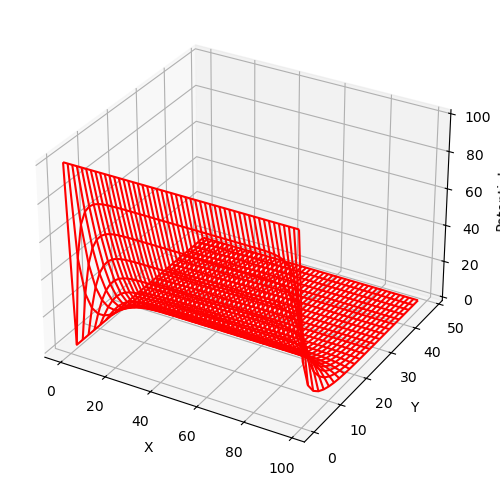

In [6]:
# LaplaceLine.py, NBotebook Version

from __future__ import division,print_function
from IPython.display import IFrame
from numpy import *

import numpy as np
import matplotlib.pylab as p
from mpl_toolkits.mplot3d import Axes3D 

Nmax = 100
Niter = 70
V = zeros((Nmax, Nmax), float)   

for k in range(0, Nmax-1): 
    V[k,0] = 100.0                  # line at 100V
    
for iter in range(Niter):                   # iterations over algorithm
    for i in range(1, Nmax-1):                                                
        for j in range(1,Nmax-1): 
            V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])  
x = range(0, Nmax-1, 2);  y = range(0, 50, 2)    # plot every other point                        
X, Y = p.meshgrid(x,y)          

def functz(V):                                  # Function returns V(x, y)
    z = V[X,Y]                        
    return z

Z = functz(V)                          
fig = p.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')                                 # plot axes
ax.plot_wireframe(X, Y, Z, color = 'r')          # red wireframe
ax.set_xlabel('X')                              # label axes
ax.set_ylabel('Y')
ax.set_zlabel('Potential')
p.show()  


# 19.5  Assessment via Surface Plot <a id="19.5"></a>

After executing `LaplaceLine.py`, you should see a surface plot like
Figure 19.1. Study this file in order to understand how to make surface
plots with Matplotlib in Python. It is important to visualize your
output as a surface plot to establish the reasonableness of the
solution.

|A |B |
|:- - -:|:- - -:|
|![image](Figs/Fig19_4a.png)|![image](Figs/Fig19_4b.png)|

**Figure 19.4** *Top:* A simple model of a parallel-plate capacitor within a
box. A realistic model would have the plates close together, in order to
condense the field, and the enclosing grounded box so large that it has no effect
on the field near the capacitor. *Bottom:* A numerical solution for the electric
potential for this geometry. The projection on the $\textit{xy}$ plane gives the
equipotential lines.

[![image](Figs/Projector.png)](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/Movies/laplace.mp4)

## 19.6  Alternate Capacitor Problems <a id="19.6"></a>

*We give you (or your instructor) a choice now. You can carry out the
assessment using our wire-plus-grounded-box problem, or you can replace
that problem with a more interesting one involving a realistic capacitor
or nonplanar capacitors. We now describe the capacitor problem and then
move on to the assessment and exploration.*


![image](Figs/Fig19_5.png)

**Figure 19.5** A guess as to how charge may rearrange itself on finite
conducting plates.

[Laplace Equation Solution Movie](http://science.oregonstate.edu/~rubin/Books/CPbook/eBook/Movies/laplace.mp4)

Elementary textbooks solve the capacitor problem for the uniform field
confined between two infinite plates. The field in a finite capacitor
varies near the edges (edge effects) and extends beyond the edges of the
capacitor (fringe fields). We model the realistic capacitor in a
grounded box (Figure 19.4) as two plates (wires) of finite length. Write
your simulation such that it is convenient to vary the grid spacing $\Delta$
and the geometry of the box and plate. We pose three versions of this
problem, each displaying somewhat different physics. In each case the
boundary condition $U=0$ on the surrounding box must be imposed for all
iterations in order to obtain a unique solution.

|A|B|
|---|---|
|![image](Figs/Fig19_6a.png)| ![image](Figs/Fig19_6b.png)| 

**Figure 19.6** *Top:* A visualization of the computed electric
    potential for a capacitor with finite width plates. *Bottom:* A
    visualization of the charge distribution along one plate determined
    by evaluating $\nabla^2 \textit{U}(\textit{x},\textit{y})$ (courtesy
    of J. Wetzel). Note the “lightening rod” effect of charge
    accumulating at corners and points.
    
1.  For the simplest version, assume that the plates are very thin
    sheets of conductors, with the top plate maintained at 100 V and the
    bottom at $-100 \mbox{V}$. Because the plates are conductors, they
    must be equipotential surfaces, and a battery can maintain them at
    constant voltages. Write or modify the given program to solve
    Laplace’s equation such that the plates have fixed voltages.

2.  For the next version of this problem, assume that the plates are
    composed of a line of dielectric material with uniform charge
    densities $\rho$ on the top and $-\rho$ on the bottom. Solve
    Poisson’s equation (19.3) in the region including the plates, and
    Laplace’s equation elsewhere. Experiment until you find a numerical
    value for $\rho$ that gives a potential similar to that shown in
    Figure 19.6 for plates with fixed voltages.

3.  For the final version of this problem investigate how the charges on
    a capacitor with finite-thickness conducting plates (Figure 19.5)
    distribute themselves. Because the plates are conductors, they are
    still equipotential surfaces at 100 and $-100 \mbox{V}$, only now
    you should make them have a thickness of at least $2\Delta$ (so we can
    see the difference between the potential near the top and the bottom
    surfaces of the plates). Such being the case, we solve Laplace’s
    equation (19.4) much as before to determine $U(x,y)$. Once we have
    $U(x,y)$, we substitute it into Poisson’s equation (19.3) and
    determine how the charge density distributes itself along the top
    and bottom surfaces of the plates. *Hint:* Because the electric
    field is no longer uniform, we know that the charge distribution
    also will no longer be uniform. In addition, because the electric
    field now extends beyond the ends of the capacitor and because field
    lines begin and end on charge, some charge may end up on the edges
    and outer surfaces of the plates (Figure 19.4).

4.  The numerical solution to our PDE can be applied to arbitrary
    boundary conditions. Two boundary conditions to explore are
    triangular and sinusoidal:

    $$\tag*{19.37}
    U(x) =\begin{cases}
     200  {x/w}, &  x \leq w/2,\\
     100(1- {x/w}), &  x \geq w/2,
     \end{cases}\qquad \mbox{or }\ \
    U(x) = 100 \sin\left(\frac{2\pi x}{w}\right).$$

5.  **Square conductors:** You have designed a piece of equipment
    consisting of a small metal box at 100 V within a larger grounded
    one (Figure 19.8). You find that sparking occurs between the boxes,
    which means that the electric field is too large. You need to
    determine where the field is greatest so that you can change the
    geometry and eliminate the sparking. Modify the program to satisfy
    these boundary conditions and to determine the field between
    the boxes. Gauss’s law tells us that the field vanishes within the
    inner box because it contains no charge. Plot the potential and
    equipotential surfaces and sketch in the electric field lines.
    Deduce where the electric field is most intense and try redesigning
    the equipment to reduce the field.

6.  **Cracked cylindrical capacitor:** You have designed the cylindrical
    capacitor containing a long outer cylinder surrounding a thin inner
    cylinder (Figure 19.8 right). The cylinders have a small crack in
    them in order to connect them to the battery that maintains the
    inner cylinder at $-100 \mbox{V}$ and outer cylinder at 100 V.
    Determine how this small crack affects the field configuration. In
    order for a unique solution to exist for this problem, place both
    cylinders within a large grounded box. Note that because our
    algorithm is based on expansion of the Laplacian in rectangular
    coordinates, you cannot just convert it to a radial and angle grid.

|A |B | 
|:- - -:|:- - -:|
|![image](Figs/Fig19_7a.png)|![image](Figs/Fig19_7b.png)|

**Figure 19.7** *A:* Computed equipotential surfaces and electric field lines
for a realistic capacitor. *B:* Equipotential surfaces and electric field lines
mapped onto the surface for a 3-D capacitor constructed from two tori.


## 19.7  Implementation and Assessment <a id="19.7"></a>

1.  Write or modify the program to find the electric potential for a
    capacitor within a grounded box. Use the labeling scheme on the left
    in Figure 19.4.

2.  To start, have your program undertake 1000 iterations and then quit.
    During debugging, examine how the potential changes in some key
    locations as you iterate toward a solution.

3.  Repeat the process for different step sizes $\Delta$ and draw
    conclusions regarding the stability and accuracy of the solution.

4.  Once your program produces reasonable solutions, modify it so that
    it stops iterating after convergence is reached, or if the number of
    iterations becomes too large. Rather than trying to discern small
    changes in highly compressed surface plots, use a numerical measure
    of precision, for example,

    $$\tag*{19.38}
    trace = \sum_{i}  |U[i,i]|,$$

    which samples the solution along the diagonal. Remember, this is a
    simple algorithm and so may require many iterations for
    high precision. You should be able to obtain changes in the trace
    that are less than 1 part in $10^4$. (The `break` command or a
    `while` loop is useful for this type of test.)

5.  Equation (19.35) expresses the **successive overrelaxation**
    technique in which convergence is accelerated by using a judicious
    choice of $\omega$. Determine by trial and error a best value of
    $\omega$. This should let you double the speed of the algorithm.

6.  Now that your code is accurate, modify it to simulate a more
    realistic capacitor in which the plate separation is approximately
    ${\frac {1}{10}}$ of the plate length. You should find the field
    more condensed and more uniform between the plates.

7.  If you are working with the wire-in-the-box problem, compare your
    numerical solution to the analytic one (19.18). Do not be surprised
    if you need to sum thousands of terms before the analytic solution
    converges!

## 19.8  Electric Field Visualization (Exploration) <a id="19.8"></a>

Plot the equipotential surfaces on a separate 2-D plot. Start with a
crude, hand-drawn sketch of the electric field by drawing curves
orthogonal to the equipotential lines, beginning and ending on the
boundaries (where the charges lie). The regions of high density are
regions of high electric field. Physics tells us that the electric field
$\mathbf{E}$ is the negative gradient of the potential:

$$\tag*{19.39}
\mathbf{E}  = - \mathbf{\nabla} U(x,y) = - \frac{\partial U(x,y)}
{\partial x}  \hat{\epsilon}_x - \frac{\partial U(x,y)}{\partial
y}  \hat{\epsilon}_y,$$

where $\hat{\epsilon}_i$ is a unit vector in the $i$ direction. While at
first it may seem that some work is involved in determining these
derivatives, once you have a solution for $U(x,y)$ on a grid, it is
simple to use the central-difference approximation for the derivative to
determine the field, for example:[{xml}](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/19.40.xml)

$$\tag*{19.40} E_x \simeq \frac{U(x+\Delta,y)-U(x-\Delta,y)}{2\Delta} = \frac{ U_{i+1,j}
-U_{i-1,j}}{2\Delta}.$$

Once you have a data file representing such a vector field, it can be
visualized by plotting arrows of varying lengths and directions, or with
just lines (Figure 19.7). In § 1.5.6 we have shown how to do this with
Mayavi.

![image](Figs/Fig19_8.png)

**Figure 19.8** *Top:* The geometry of a capacitor formed by placing two
long, square cylinders within each other. *Bottom:* The geometry of a capacitor
formed by placing two long, circular cylinders within each other. The cylinders
are cracked on the side so that wires can enter the region.

## 19.9  Review Exercise <a id="19.9"></a>

You are given a simple Laplace-type equation $$\tag*{19.41}
\frac{\partial u}{\partial x} + \frac{\partial u}{\partial y} = -
\rho(x,y),$$

where $x$ and $y$ are Cartesian spatial coordinates and $\rho(x,y)$ is
the charge density in space.

1.  Develop a simple algorithm that will permit you to solve for the
    potential $u$ between two square conductors kept at fixed $u$, with
    a charge density $\rho$ between them.

2.  Make a simple sketch that shows with arrows how your
    algorithm works.

3.  Make sure to specify how you start and terminate the algorithm.

4.  **Thinking outside the box$\odot$**: Find the electric potential for
    all points *outside* the charge-free square shown in Figure 19.1. Is
    your solution unique?